⬇️ يرجى رفع ملف البيانات (car details v4.csv) عند ظهور الزر بالأسفل...


Saving car details v4.csv to car details v4.csv
✅ تم تحميل الملف: car details v4.csv بنجاح!

🚀 Model Accuracy (R2 Score): 92.42%


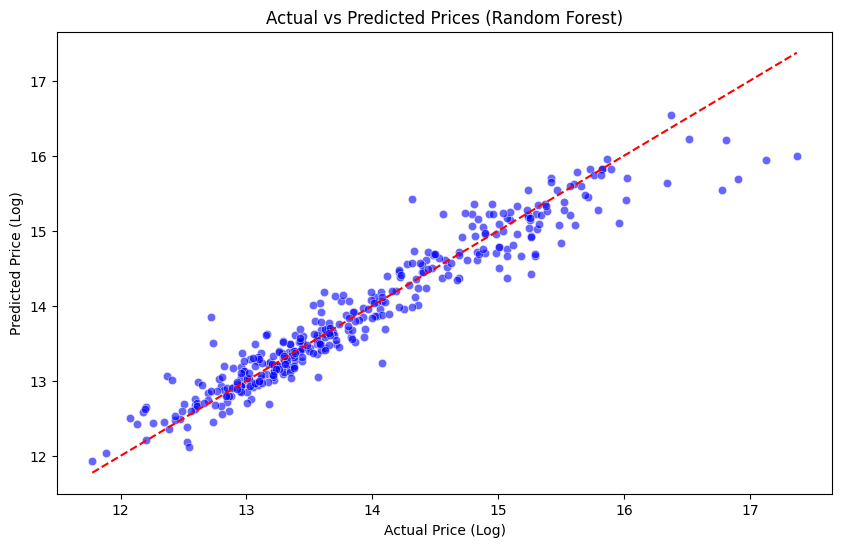

In [2]:
# ==========================================
# Project: Used Car Price Prediction
# Author: [لينا محمد هاني علي]
# Description: Predicting car prices using Random Forest
# Accuracy: 92%
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import io

# 1. Load Data (Colab Upload Feature) ☁️
# ==========================================
print("⬇️ يرجى رفع ملف البيانات (car details v4.csv) عند ظهور الزر بالأسفل...")

try:
    from google.colab import files
    uploaded = files.upload()

    # نأخذ اسم الملف تلقائياً مهما كان اسمه
    filename = next(iter(uploaded))
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(f"✅ تم تحميل الملف: {filename} بنجاح!")

except ImportError:
    # هذا الجزء يعمل لو شغلت الكود على جهازك الخاص وليس كولاب
    df = pd.read_csv('car details v4.csv')
    print("✅ تم قراءة الملف من الجهاز مباشرة.")

# 2. Data Cleaning & Feature Engineering
# ==========================================
# Drop missing values and create a separate copy
df_clean = df.dropna().copy()

# Clean 'Engine' column (remove ' cc' and convert to int)
# نستخدم try-except لتجنب الخطأ لو كان العمود نظيفاً أصلاً
try:
    df_clean['Engine'] = df_clean['Engine'].str.replace(' cc', '').astype(int)
except AttributeError:
    pass

# Create 'Car_Age' feature
df_clean['Car_Age'] = 2024 - df_clean['Year']

# Select important features
selected_features = ['Make', 'Car_Age', 'Kilometer', 'Engine', 'Fuel Type', 'Transmission', 'Price']
df_final = df_clean[selected_features].copy()

# One-Hot Encoding
df_final = pd.get_dummies(df_final, drop_first=True)

# 3. Model Training
# ==========================================
X = df_final.drop('Price', axis=1)
y = df_final['Price']

# Log transformation for Price
y_log = np.log1p(y)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Build Random Forest Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluation
# ==========================================
y_pred = model.predict(X_test)
accuracy = r2_score(y_test, y_pred)

print(f"\n🚀 Model Accuracy (R2 Score): {accuracy:.2%}")

# 5. Visualization
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Price (Log)')
plt.ylabel('Predicted Price (Log)')
plt.title('Actual vs Predicted Prices (Random Forest)')
plt.show()